In [13]:
import kagglehub
import torch.nn.functional as F
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms


In [14]:
# Download latest version
path = kagglehub.dataset_download("subhaditya/fer2013plus")

print("Path to dataset files:", path)

Path to dataset files: /home/omarhammad/.cache/kagglehub/datasets/subhaditya/fer2013plus/versions/1


In [15]:

data_transforms = {
    "train": transforms.Compose([
        transforms.Grayscale(num_output_channels=1),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(10),
        transforms.RandomCrop(48, padding=4),
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))
    ]),
    "test": transforms.Compose([
        transforms.Grayscale(num_output_channels=1),
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))
    ])
}

# Paths to dataset
train_dir = path + "/fer2013plus/fer2013/train"
test_dir = path + "/fer2013plus/fer2013/test"

# Create datasets
train_dataset = datasets.ImageFolder(train_dir, transform=data_transforms["train"])
test_dataset = datasets.ImageFolder(test_dir, transform=data_transforms["test"])

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=True)

print("Train loader and test loader created!")

# Check a sample batch
images, labels = next(iter(train_loader))

print("Image batch shape:", images.shape)
print("Labels batch shape:", labels.shape)
print("Labels:", labels)

# Get class-to-label mapping
class_names = train_dataset.classes
print("Class Names:", class_names)

# Example: label 0 corresponds to the first class
print("Label 0 is:", class_names[0])


Train loader and test loader created!
Image batch shape: torch.Size([16, 1, 48, 48])
Labels batch shape: torch.Size([16])
Labels: tensor([3, 5, 6, 4, 3, 4, 4, 6, 4, 5, 4, 7, 7, 5, 5, 7])
Class Names: ['anger', 'contempt', 'disgust', 'fear', 'happiness', 'neutral', 'sadness', 'surprise']
Label 0 is: anger


In [16]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, stride=1, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2, padding=0)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=1, padding=1)
        self.conv3 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, stride=1, padding=1)
        self.fc1 = nn.Linear(in_features=128 * 6 * 6, out_features=256)
        self.fc2 = nn.Linear(in_features=256, out_features=8)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        x = x.view(-1, 128 * 6 * 6)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

In [17]:
def train_model(model, train_loader, val_loader, optimizer, criterion, num_epochs=10, print_every=100, patience=5):
    """
    Trains a given model with early stopping and specified parameters.

    Args:
        model: The model to train.
        train_loader: DataLoader for the training dataset.
        val_loader: DataLoader for the validation dataset.
        optimizer: Optimizer for training (e.g., Adam, SGD).
        criterion: Loss function (e.g., CrossEntropyLoss).
        num_epochs: Number of training epochs.
        print_every: Frequency (in batches) to print training loss.
        patience: Number of epochs to wait for validation loss improvement before stopping.
    """
    best_val_loss = float('inf')
    patience_counter = 0

    for epoch in range(num_epochs):
        model.train()  # Set the model to training mode
        running_loss = 0.0

        for i, (inputs, labels) in enumerate(train_loader):
            # Zero the parameter gradients
            optimizer.zero_grad()

            # Forward pass
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            # Backward pass
            loss.backward()
            optimizer.step()

            # Accumulate the loss
            running_loss += loss.item()

            # Print progress
            if (i + 1) % print_every == 0:
                print(
                    f"Epoch [{epoch + 1}/{num_epochs}], "
                    f"Step [{i + 1}/{len(train_loader)}], "
                    f"Loss: {running_loss / print_every:.4f}"
                )
                running_loss = 0.0

        # Validation phase
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for inputs, labels in val_loader:
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
        val_loss /= len(val_loader)

        print(f"Epoch [{epoch + 1}/{num_epochs}], Validation Loss: {val_loss:.4f}")

        # Check for early stopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0  # Reset patience counter if improvement
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"Early stopping triggered at epoch {epoch + 1}")
                break


In [18]:
def evaluate_model(model, data_loader):
    """
    Evaluates the model's performance on a given dataset.

    Args:
        model: The trained model to evaluate.
        data_loader: DataLoader for the dataset to evaluate.

    Returns:
        float: Accuracy of the model on the dataset.
    """
    model.eval()  # Set model to evaluation mode
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in data_loader:
            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = correct / total
    print(f"Accuracy: {accuracy:.4f}")
    return accuracy


In [19]:
import matplotlib.pyplot as plt
import torch

def visualize_predictions_with_original_images(model, data_loader, classes, num_images=8, device='cpu'):
    """
    Visualizes original images with ground truth and predicted labels.

    Args:
        model: The trained model to use for predictions.
        data_loader: DataLoader for the dataset to evaluate.
        classes: List of class names corresponding to the labels.
        num_images: Number of images to visualize (default is 8).
        device: Device to use for model and data ('cpu' or 'cuda').

    """
    # Set model to evaluation mode
    model.eval()
    model.to(device)

    # Get a random batch of data
    dataiter = iter(data_loader)
    images, labels = next(dataiter)
    images, labels = images.to(device), labels.to(device)

    # Get predictions from the model
    with torch.no_grad():
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

    # Limit the number of images to visualize
    num_images = min(num_images, len(images))

    # Create a grid of images
    rows = (num_images + 1) // 2  # Number of rows for layout
    cols = 2  # Fixed number of columns

    plt.figure(figsize=(15, rows * 5))  # Adjust figure size
    for i in range(num_images):
        ax = plt.subplot(rows, cols, i + 1)

        # Convert tensor to numpy array for display
        img = images[i].cpu().permute(1, 2, 0).numpy()  # Rearrange dimensions for matplotlib

        plt.imshow(img)  # Display the original image

        # Add ground truth and predicted labels
        true_label = classes[labels[i].item()]
        pred_label = classes[predicted[i].item()]
        ax.set_title(f"True: {true_label}\nPred: {pred_label}", fontsize=12)
        plt.axis("off")
    plt.tight_layout()
    plt.show()


In [20]:
from skopt.space import Real, Integer, Categorical

search_space = [
    Real(1e-4, 1e-2, name='learning_rate', prior='log-uniform'),
    Integer(16, 32, name='batch_size'),  # Smaller batch size range
    Categorical(['Adam'], name='optimizer'),  # Fixed optimizer
    Integer(3, 5, name='patience')  # Early stopping patience
]


In [21]:
def objective(params):
    learning_rate, batch_size, optimizer_type, patience = params
    batch_size = int(batch_size)
    patience = int(patience)

    # Set the device (use GPU if available, otherwise CPU)
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    # Update data loaders
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    # Define model, criterion, and optimizer
    model = CNN().to(device)  # Move model to GPU
    criterion = nn.CrossEntropyLoss()
    optimizer = getattr(torch.optim, optimizer_type)(model.parameters(), lr=learning_rate)

    # Early stopping logic
    best_val_loss = float('inf')
    patience_counter = 0

    print(f"Starting training with params: lr={learning_rate}, batch_size={batch_size}, optimizer={optimizer_type}, patience={patience}, device={device}")

    for epoch in range(25):  # Use a high fixed max epoch value
        model.train()
        running_loss = 0.0

        # Training loop
        for batch_idx, (inputs, labels) in enumerate(train_loader):
            inputs, labels = inputs.to(device), labels.to(device)  # Move data to GPU
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

            # Print batch progress
            if (batch_idx + 1) % 100 == 0:  # Every 100 batches
                print(f"Epoch [{epoch + 1}/25], Batch [{batch_idx + 1}/{len(train_loader)}], Loss: {loss.item():.4f}")

        # Validation loss
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)  # Move data to GPU
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
        val_loss /= len(val_loader)

        print(f"Epoch [{epoch + 1}/25], Validation Loss: {val_loss:.4f}")

        # Early stopping
        if val_loss < best_val_loss:
            print(f"Validation loss improved from {best_val_loss:.4f} to {val_loss:.4f}")
            best_val_loss = val_loss
            patience_counter = 0  # Reset patience counter if improvement
        else:
            patience_counter += 1
            print(f"No improvement in validation loss. Patience counter: {patience_counter}/{patience}")

            if patience_counter >= patience:
                print(f"Early stopping triggered after {epoch + 1} epochs")
                break

    # Calculate validation accuracy
    total, correct = 0, 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)  # Move data to GPU
            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_accuracy = correct / total
    print(f"Final Validation Accuracy: {val_accuracy:.4f}")
    return -val_accuracy


In [22]:
from skopt import gp_minimize

result = gp_minimize(
    func=objective,
    dimensions=search_space,
    n_calls=10,  # Reduced iterations
    random_state=42
)

print("Best parameters:", result.x)
print("Best validation accuracy:", -result.fun)


Starting training with params: lr=0.003918194347141745, batch_size=19, optimizer=Adam, patience=4, device=cuda
Epoch [1/25], Batch [100/1494], Loss: 1.7045
Epoch [1/25], Batch [200/1494], Loss: 1.4789
Epoch [1/25], Batch [300/1494], Loss: 1.4875
Epoch [1/25], Batch [400/1494], Loss: 1.4844
Epoch [1/25], Batch [500/1494], Loss: 1.3591
Epoch [1/25], Batch [600/1494], Loss: 1.5449
Epoch [1/25], Batch [700/1494], Loss: 1.6362
Epoch [1/25], Batch [800/1494], Loss: 1.6104
Epoch [1/25], Batch [900/1494], Loss: 1.4175
Epoch [1/25], Batch [1000/1494], Loss: 1.6579
Epoch [1/25], Batch [1100/1494], Loss: 1.5055
Epoch [1/25], Batch [1200/1494], Loss: 1.4547
Epoch [1/25], Batch [1300/1494], Loss: 1.5125
Epoch [1/25], Batch [1400/1494], Loss: 1.4164
Epoch [1/25], Validation Loss: 1.6211
Validation loss improved from inf to 1.6211
Epoch [2/25], Batch [100/1494], Loss: 1.2332
Epoch [2/25], Batch [200/1494], Loss: 1.5468
Epoch [2/25], Batch [300/1494], Loss: 1.3547
Epoch [2/25], Batch [400/1494], Loss:

In [24]:
# Extract best parameters from tuning results
#Best parameters: [0.0007792297153882995, np.int64(18), 'Adam', np.int64(4)]
best_learning_rate = result.x[0]
best_batch_size = int(result.x[1])
best_optimizer_type = result.x[2]
best_patience = int(result.x[3])

# Update data loaders with the best batch size
train_loader = DataLoader(train_dataset, batch_size=best_batch_size, shuffle=True)
val_loader = DataLoader(test_dataset, batch_size=best_batch_size, shuffle=False)

# Define the model, criterion, and optimizer
best_cnn_model = CNN()
criterion = nn.CrossEntropyLoss()
optimizer = getattr(torch.optim, best_optimizer_type)(best_cnn_model.parameters(), lr=best_learning_rate)

# Train the model with early stopping
train_model(
    model=best_cnn_model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    criterion=criterion,
    num_epochs=50,  # High fixed value, let early stopping decide
    print_every=100,
    patience=best_patience
)


Epoch [1/50], Step [100/1577], Loss: 1.6410
Epoch [1/50], Step [200/1577], Loss: 1.5442
Epoch [1/50], Step [300/1577], Loss: 1.5459
Epoch [1/50], Step [400/1577], Loss: 1.5517
Epoch [1/50], Step [500/1577], Loss: 1.4960
Epoch [1/50], Step [600/1577], Loss: 1.4360
Epoch [1/50], Step [700/1577], Loss: 1.4300
Epoch [1/50], Step [800/1577], Loss: 1.3168
Epoch [1/50], Step [900/1577], Loss: 1.3526
Epoch [1/50], Step [1000/1577], Loss: 1.2761
Epoch [1/50], Step [1100/1577], Loss: 1.2976
Epoch [1/50], Step [1200/1577], Loss: 1.2743
Epoch [1/50], Step [1300/1577], Loss: 1.2282
Epoch [1/50], Step [1400/1577], Loss: 1.1460
Epoch [1/50], Step [1500/1577], Loss: 1.1517
Epoch [1/50], Validation Loss: 1.0801
Epoch [2/50], Step [100/1577], Loss: 1.1147
Epoch [2/50], Step [200/1577], Loss: 1.1225
Epoch [2/50], Step [300/1577], Loss: 1.1030
Epoch [2/50], Step [400/1577], Loss: 1.1054
Epoch [2/50], Step [500/1577], Loss: 1.0585
Epoch [2/50], Step [600/1577], Loss: 1.0568
Epoch [2/50], Step [700/1577], L

In [25]:
torch.save(best_cnn_model.state_dict(), 'best_cnn_model.pth')


In [26]:
loaded_cnn_model = CNN()
loaded_cnn_model.load_state_dict(torch.load("best_cnn_model.pth", weights_only=True))

<All keys matched successfully>

In [27]:
test_accuracy = evaluate_model(loaded_cnn_model, test_loader)
print(f"Test Accuracy: {test_accuracy:.4f}")

Accuracy: 0.7688
Test Accuracy: 0.7688


In [29]:
# Prepare to count predictions for each class
classes = train_dataset.classes  # Get class names from the dataset
correct_pred = {classname: 0 for classname in classes}
total_pred = {classname: 0 for classname in classes}

# Disable gradients for evaluation
with torch.no_grad():
    for data in test_loader:
        images, labels = data
        outputs = loaded_cnn_model(images)
        _, predictions = torch.max(outputs, 1)  # Get predicted class indices

        # Collect the correct predictions for each class
        for label, prediction in zip(labels, predictions):
            label_name = classes[label]  # Convert label index to class name
            if label == prediction:
                correct_pred[label_name] += 1
            total_pred[label_name] += 1

# Print accuracy for each class
for classname, correct_count in correct_pred.items():
    if total_pred[classname] > 0:  # Avoid division by zero
        accuracy = 100 * float(correct_count) / total_pred[classname]
        print(f'Accuracy for class: {classname:10s} is {accuracy:.1f} %')
    else:
        print(f'No predictions for class: {classname}')


Accuracy for class: anger      is 68.2 %
Accuracy for class: contempt   is 13.7 %
Accuracy for class: disgust    is 31.6 %
Accuracy for class: fear       is 35.3 %
Accuracy for class: happiness  is 87.9 %
Accuracy for class: neutral    is 86.3 %
Accuracy for class: sadness    is 40.7 %
Accuracy for class: surprise   is 82.2 %


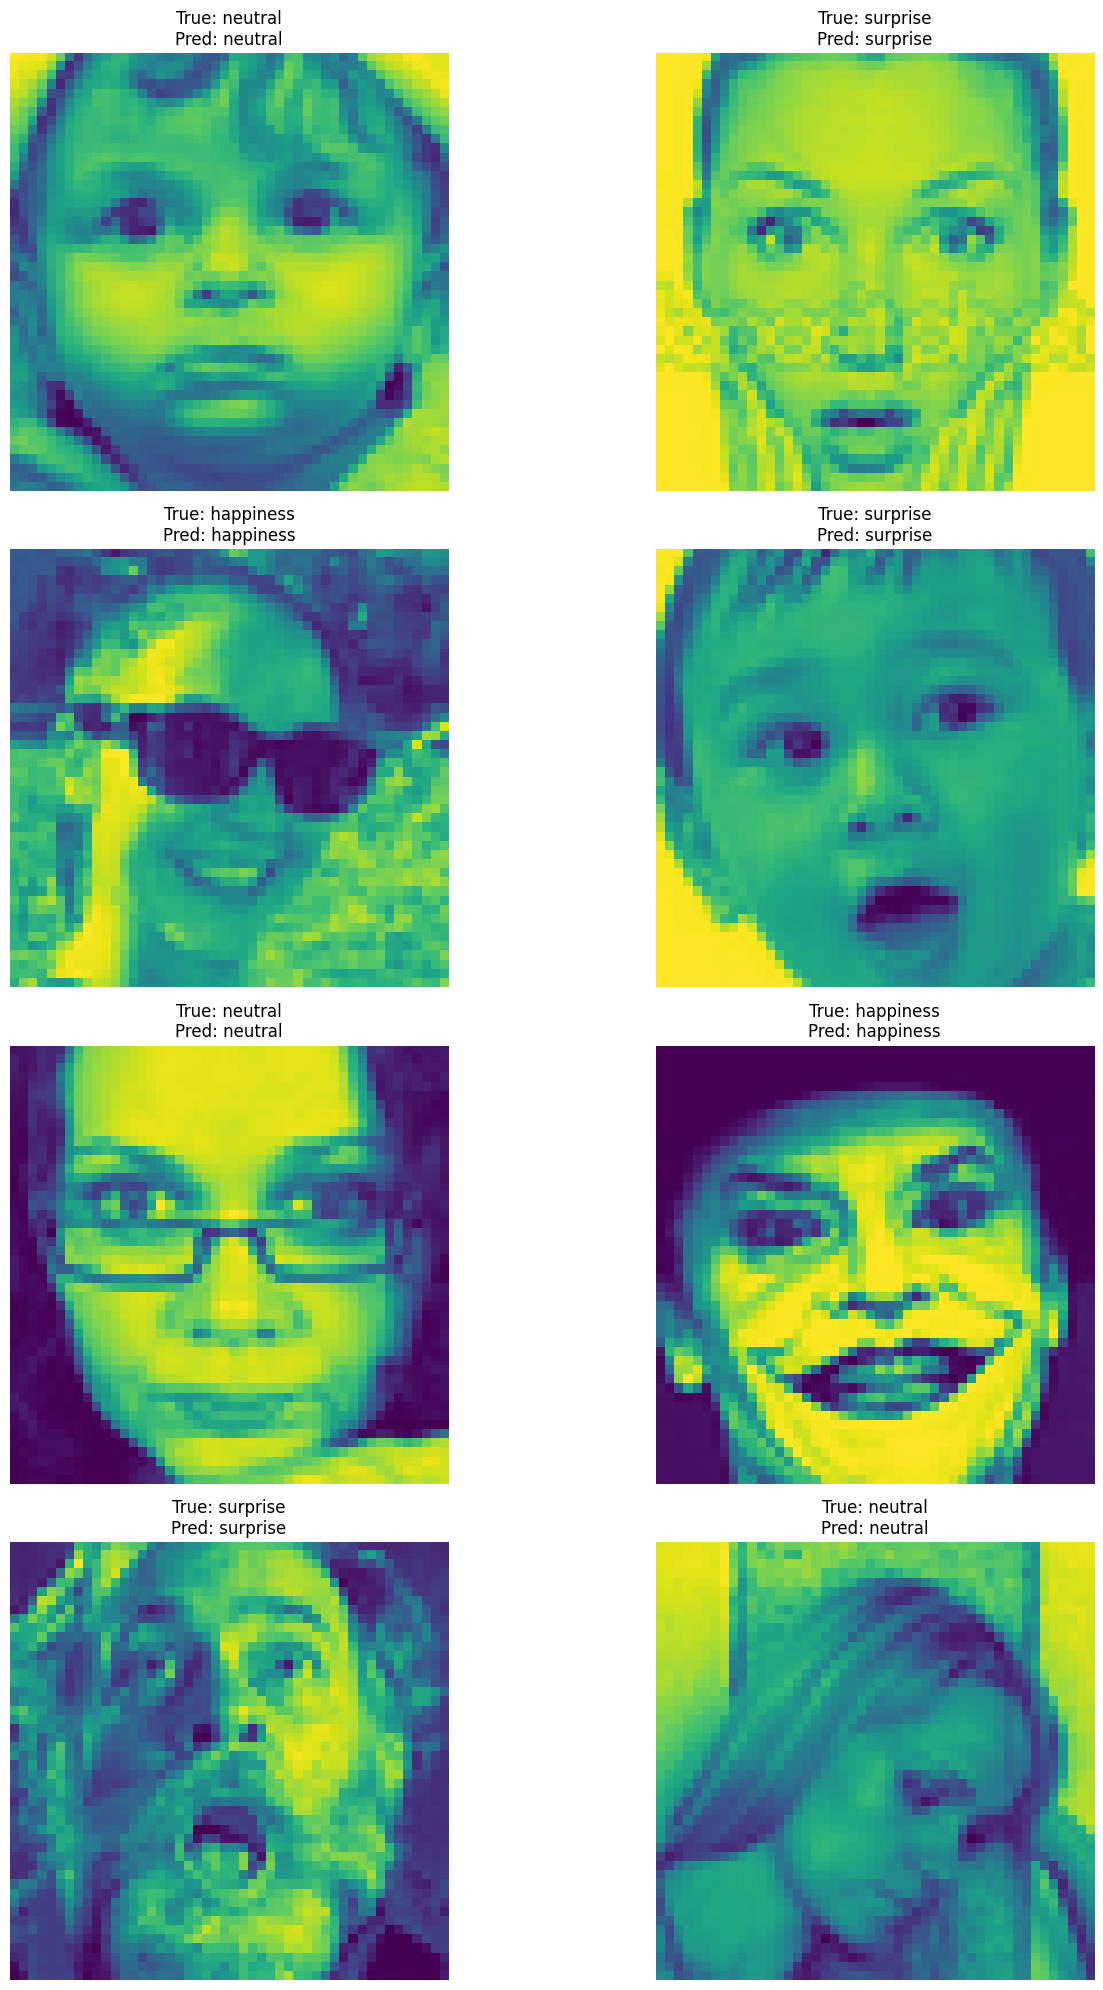

In [28]:
# Define class names
classes = train_dataset.classes  # Assuming you use ImageFolder or a similar dataset

# Visualize predictions
visualize_predictions_with_original_images(
    model=loaded_cnn_model,        # Your trained model
    data_loader=test_loader,  # DataLoader for the test dataset
    classes=classes,          # Class names
    num_images=8,             # Number of images to visualize
    device='cpu'              # Use 'cuda' if running on GPU
)